# NumPy_ML Demo
### MNIST Supervised Learning Classification
Author: DarelleQ

Github: https://github.com/darelleq/NumPy_ML

License: Attribution-NonCommercial-ShareAlike 4.0 International

In [ ]:
import io
import math
from pathlib import Path
from typing import Final

import numpy as np
from numpy.typing import NDArray
import polars as pl
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets
from tqdm.notebook import tqdm
from rich import pretty
from rich.console import Console
from torch.utils.data import Dataset # Only for fetching MNIST
from IPython.display import display, SVG

from numpy_ml.initialisers import Initialiser, Standard_Normal, Xavier_Normal, Kaiming_Normal
from numpy_ml.layers import Layer, ReLU, ReLU6, LeakyReLU, Sigmoid, Softmax, Dense, Conv2D, Reshape
from numpy_ml.networks import NeuralNetwork, Sequential
from numpy_ml.optimisers import Optimiser, Adam
from numpy_ml.data_handlers import MiniBatcher
from numpy_ml.criterions import CrossEntropyLoss
from numpy_ml.eval import ConfusionMatrix

In [2]:
# notebook setup
pretty.install()
matplotlib.use('notebook') # Change if required 
matplotlib.rcParams['font.family'] = 'Times New Roman'
plt.style.use('seaborn-v0_8')

# Globals (more globals in hyper-parameter block)
CWD: Final[Path] = Path.cwd()
DEMO_DATA_DIR: Final[Path] = CWD / 'demo_data'
# This will organise a directory within your wd to house the data
if not DEMO_DATA_DIR.exists():
    DEMO_DATA_DIR.mkdir(exist_ok=False)
EMNIST_ROOT: Final[Path] = DEMO_DATA_DIR / 'emnist'

console = Console()

MNIST_IMAGE_SIZE: Final[tuple[int, int]] = (28, 28)
MNIST_FEATURES: Final[int] = 28 * 28
MNIST_CATEGORIES: Final[int] = 10

## Model Hyperparameters
User defined Hyper-parameters should be defined here and only here 

In [3]:
LAYERS: list[Layer] = [
    Conv2D(out_channels=8, in_channels=1, kern_height=5, kern_width=5, strides=(2, 2), mode='valid'),
    LeakyReLU(alpha=0.1),

    Conv2D(out_channels=4, in_channels=8, kern_height=3, kern_width=3, strides=(1, 1), mode='valid'),
    LeakyReLU(alpha=0.1),

    Reshape(from_shape=(-1, 4, 10, 10), to_shape=(-1, 400)),

    Dense(out_features=256, in_features=400),
    LeakyReLU(alpha=0.1),

    Dense(256, MNIST_CATEGORIES),
    Softmax() # Final Layer must be Softmax
]

# Adam hyper-parameters
LR: float = 0.001
ADAM_BETA1: float = 0.9
ADAM_BETA2: float = 0.999

EPOCHS: int = 3
BATCHSIZE: int = 128
USE_RESIDUALS: bool = False # Instructs no training on residual samples that couldn't be batched into a full-sized batch

# Entropy control
GLOB_RNG_SEED: int = 10
GLOB_RNG_BIT_GENERATOR: type[np.random.BitGenerator] = np.random.PCG64
GLOB_RNG: np.random.Generator = np.random.Generator(GLOB_RNG_BIT_GENERATOR(GLOB_RNG_SEED))
Initialiser.rng = GLOB_RNG
MiniBatcher.rng = GLOB_RNG

In [4]:
# Hyper-parameter validation 
assert type(LAYERS[-1]) == Softmax, TypeError("Expected Softmax Final Layer for MNIST")
assert type(LAYERS[-2]) == Dense and LAYERS[-2].out_features == 10, ("Expected final Dense with 10 nodes for MNIST.")
assert 0 < LR <= 1, "LEARNING_RATE must be greater than 0 and less than or equal to 1."
assert 0 < ADAM_BETA1 <= 1, "ADAM_BETA1 must be greater than 0 and less than or equal to 1."
assert 0 < ADAM_BETA2 <= 1, "ADAM_BETA2 must be greater than 0 and less than or equal to 1."

## All notebook specific methods defined here
Specifically:
<ul>
    <li> Fetching MNIST data </li>
    <li> Standardised Network Creation </li>
    <li> Standardised Adam Optimiser Creation </li>
    <li> Training loop </li>
    <li> Evaluation </li>
</ul>

In [ ]:
type ProcessedData = tuple[NDArray[np.uint8], NDArray[np.float32], NDArray[np.float32]]

def fetch_raw_data(training: bool) -> Dataset:
    # Fetches (and downloads if required) pytorch's EMNIST, MNIST extracted with split='digits'

    return datasets.EMNIST(EMNIST_ROOT, split='digits', train=training, download=True)

def preprocess_raw_data(raw_data: Dataset) -> ProcessedData:
    labels: np.ndarray[tuple[int], np.uint8]
    onehots: np.ndarray[tuple[int, int], np.float32]
    features: np.ndarray[tuple[int, ...], np.float32]

    # uint8 (m,) Vector 
    labels = raw_data.targets.numpy(force=True).astype(np.uint8)

    # float32 (m, 10) Matrix; One-hot dummy label matrix 
    onehots = np.eye(MNIST_CATEGORIES, dtype=np.float32)[labels]

    # float32 (m, 28, 28) Rank 3 Tensor; 8-bit greyscale normalised
    features = np.divide(raw_data.data.numpy(force=True), 255, dtype=np.float32)

    # Reshape features appropriately 
    # assumes sequential setup with single Conv block followed by Dense block
    if any(layer.__class__.__name__ in ['Conv2D', 'MaxPool2D', 'AvgPool2D'] for layer in LAYERS):
        # Reshapes as a rank 4 Tenor for 2D feature analysis
        features = features.reshape(-1, 1, 28, 28)

    else:
        # Reshapes as a Matrix for 1D feature analysis
        features = features.reshape(-1, 28 * 28)

    assert features.min() == 0
    assert features.max() == 1

    return labels, onehots, features

def spawn_standard_nn():
    model = Sequential(LAYERS, name='MNIST Classifier', check_probability=1)
    model.initialise()

    return model

def spawn_standard_optimiser(nn: NeuralNetwork, lr: float, beta1: float, beta2: float):

    return Adam(network=nn, lr=lr, beta1=beta1, beta2=beta2)
    
def greedy_prediction(pred_probs: np.ndarray[tuple[int, int], np.dtype[np.float32]]):
    assert pred_probs.ndim == 2

    return np.astype(np.argmax(pred_probs, axis=1), np.uint8)

def fit(nn: NeuralNetwork, optim: Optimiser):
    data: ProcessedData = preprocess_raw_data(fetch_raw_data(training=True))

    batcher = MiniBatcher(data, batchsize=BATCHSIZE, use_residuals=USE_RESIDUALS) 

    n_batches = len(batcher)

    training_losses = np.zeros((EPOCHS, n_batches), np.float64)

    training_accuracies = np.zeros((EPOCHS, n_batches), np.float64)

    for epoch in tqdm(range(EPOCHS), desc='Training Epochs'):

        for k, minibatch in tqdm(enumerate(batcher), 'Mini-batch', total=n_batches, leave=False):
            labels, onehots, features = minibatch

            u = nn.forward(features)

            pred_labels = greedy_prediction(u)
            criterion = CrossEntropyLoss(prob_true=onehots, prob_pred=u)

            training_losses[epoch, k] = criterion.avg_loss
            training_accuracies[epoch, k] = np.mean(np.equal(labels, pred_labels), dtype=np.float64)

            nn.backward(criterion.dcost_dpred)

            optim.step()

    return training_losses, training_accuracies


def evaluate(nn: NeuralNetwork) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    data: ProcessedData = preprocess_raw_data(fetch_raw_data(training=False))

    with tqdm(range(1), 'Evaluating') as pbar:
        labels, onehots, features = data

        u: NDArray[np.float32] = nn.forward(features)
        pred_labels: NDArray[np.uint8] = greedy_prediction(u)

        criterion = CrossEntropyLoss(prob_true=onehots, prob_pred=u)
        losses: NDArray[np.float64] = np.astype(criterion.losses, np.float64)
        accuracy: NDArray[np.float64] = np.mean(np.equal(labels, pred_labels), dtype=np.float64)

        pbar.update()

    return losses, accuracy, labels, pred_labels

## Running Lab

In [6]:
nn = spawn_standard_nn()
adam = spawn_standard_optimiser(nn, lr=LR, beta1=ADAM_BETA1, beta2=ADAM_BETA2)

In [7]:
pretrain_eval_metrics = evaluate(nn)

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
training_metrics = fit(nn, adam)

Training Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Mini-batch:   0%|          | 0/1875 [00:00<?, ?it/s]

Mini-batch:   0%|          | 0/1875 [00:00<?, ?it/s]

Mini-batch:   0%|          | 0/1875 [00:00<?, ?it/s]

In [9]:
eval_metrics = evaluate(nn)

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

## Plotting Pre-training Metrics
Baseline metrics

Percentage Correct: 13.7475%

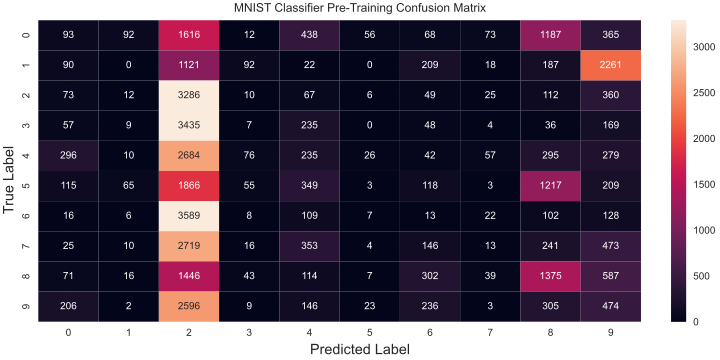

In [10]:
eval_losses, eval_accuracy, eval_labels, eval_pred_labels = pretrain_eval_metrics

console.print(f"Percentage Correct: {eval_accuracy:.4%}")

confusion_matrix = ConfusionMatrix(10, true_labels=eval_labels, pred_labels=eval_pred_labels)

fig = plt.figure(figsize=(10, 5), layout='constrained')
fig.suptitle(f"{nn.name} Pre-Training Confusion Matrix")
fig.supylabel(f"True Label", fontsize='x-large')
fig.supxlabel(f"Predicted Label", fontsize='x-large')

ax = fig.subplots()

hmap = sns.heatmap(confusion_matrix.array, robust=True, cbar=True, annot=True, fmt='d', ax=ax, linewidth=0.05)

# Just a more flexible and reliable way I like to preview my plots
buffer: io.BytesIO = io.BytesIO()
with buffer:
    fig.savefig(buffer, format='svg')
    buffer.seek(0)
    display(SVG(buffer.read()))
    plt.close(fig)

## Plotting Training Metrics

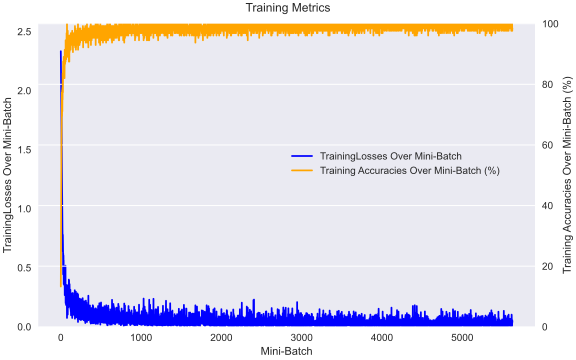

In [11]:
training_losses, training_accuracies = training_metrics

df_train: pl.DataFrame = pl.DataFrame({
    "losses": training_losses.flatten(),
    "accuracy": training_accuracies.flatten() * 100
})

fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
fig.suptitle("Training Metrics")
ax_label: str="TrainingLosses Over Mini-Batch"

ax.plot(df_train['losses'], color='blue', label=ax_label)
ax.set(
    ylim=(0, df_train['losses'].max() * 1.1),
    label=ax_label,
    ylabel=ax_label,
    xlabel='Mini-Batch'
)
ax.grid()

twax = ax.twinx()
twax_label = "Training Accuracies Over Mini-Batch (%)"
twax.plot(df_train['accuracy'], color='orange', label=twax_label)
twax.set(
    ylim=(0, 100),
    ylabel=twax_label
)

fig.legend()
sns.move_legend(fig, loc=(0.5, 0.5))

# Just a more flexible and reliable way I like to preview my plots
buffer: io.BytesIO = io.BytesIO()
with buffer:
    fig.savefig(buffer, format='svg')
    buffer.seek(0)
    display(SVG(buffer.read()))
    plt.close(fig)


# Post-Training Evaluation Metrics

Percentage Correct: 98.9050%; 
surely we don't need a stats test

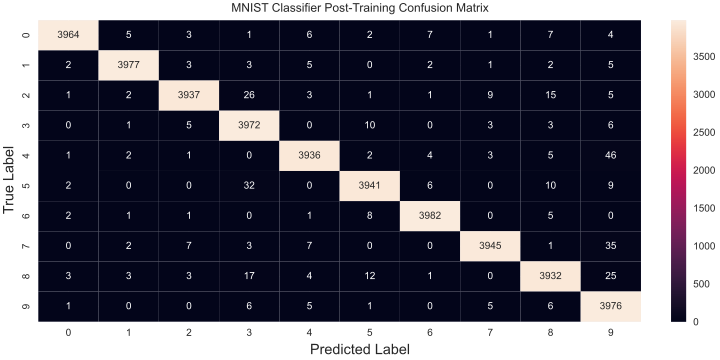

In [14]:
eval_losses, eval_accuracy, eval_labels, eval_pred_labels = eval_metrics

console.print(f"Percentage Correct: {eval_accuracy:.4%}; \nsurely we don't need a stats test")

confusion_matrix = ConfusionMatrix(10, true_labels=eval_labels, pred_labels=eval_pred_labels)

fig = plt.figure(figsize=(10, 5), layout='constrained')
fig.suptitle(f"{nn.name} Post-Training Confusion Matrix")
fig.supylabel(f"True Label", fontsize='x-large')
fig.supxlabel(f"Predicted Label", fontsize='x-large')

ax = fig.subplots()

hmap = sns.heatmap(confusion_matrix.array, robust=True, cbar=True, annot=True, fmt='d', ax=ax, linewidth=0.05)

# Just a more flexible and reliable way I like to preview my plots
buffer: io.BytesIO = io.BytesIO()
with buffer:
    fig.savefig(buffer, format='svg')
    buffer.seek(0)
    display(SVG(buffer.read()))
    plt.close(fig)

### Note:
If the hyper-parameters have been changed and you observed the post-training plot exclusively highlighting a single column (i.e. everything black except one column), the likely culprit is an instability of the gradients leading to a breakdown of the weights. This is best fixed with an investigation and adjustment of your hyperparameters, such as network size, batchsize, learning rate, adam parameters, etc etc. It is also possible Theta may have just converged somewhere extremely sub-optimal but if you find that even after changing the RNG seed the error still occurs, its likely that my numpy based float32 library is just not cut out for the application of the specific parameters. :)


<strong>Thanks for exploring my work!</strong>